# Imports

In [10]:
import numpy as np 
import h5py
import warnings

from egb_jax_eccentric import (
    EccentricBinaryParams,
    aet_from_xyz,
    eccentric_complex_strain,
    eccentric_links_jax,
    eccentric_xyz_jax,
    lisa_orbit,
    precompute_jax_link_geometry,
    default_lisaorbits, 
    state_from_lisaorbits
)
from egb_jax_eccentric.constants import PARSEC_M, KILOPARSEC_M
from astropy.coordinates import SkyCoord, BarycentricTrueEcliptic
import astropy.units as u
import json
from scipy.signal import welch
import matplotlib.pyplot as plt


In [ ]:
import os
work_dir='/home/svu/e1498138/localgit/eGB-multi'
scratch_dir='/scratch/e1498138/eGB-multi'
os.chdir(work_dir)

inj_path = scratch_dir + '/data/sangria_hmcnc.h5'

# Read injected file

In [5]:
XYZ = ("X", "Y", "Z")
AET = ("A", "E", "T")

In [6]:
with h5py.File(inj_path, "r") as f:
    t = f["t"][:]
    noise_xyz = {"t": t, **{ch: f["noise"][ch][:] for ch in XYZ}}
    signal_xyz = {ch: f["eccentric_signal"][ch][:] for ch in XYZ}
    injected_xyz = {"t": t, **{ch: f["injected"][ch][:] for ch in XYZ}}

    dt = f.attrs["segment_dt_s"]
    sangria_metadata = json.loads(f.attrs["sangria_metadata_json"])
    source_params = json.loads(f.attrs["egb_source_params_json"])

print("samples:", t.size, "dt:", dt)
print("source_params:", json.dumps(source_params, indent=2))


samples: 17280 dt: 5.0
source_params: {
  "f0_hz": 0.00622027623506547,
  "eccentricity": 0.1,
  "m1_solar": 0.55,
  "m2_solar": 0.27,
  "distance_m": 2.3142581861185254e+20,
  "beta": -0.08210049881437637,
  "lambda_": 2.102052384246663,
  "psi": 0.0,
  "inclination": 0.6632251157578453,
  "phi0": 0.0,
  "fdot": 0.0
}


# Rotate to AET & PSD Estimate

In [15]:
noise_aet = aet_from_xyz(noise_xyz)
signal_aet = aet_from_xyz(signal_xyz)
injected_aet = aet_from_xyz(injected_xyz)

print("noise AET max abs:", {ch: float(np.max(np.abs(noise_aet[ch]))) for ch in ("A", "E", "T")})
print("signal AET max abs:", {ch: float(np.max(np.abs(signal_aet[ch]))) for ch in ("A", "E", "T")})


noise AET max abs: {'A': 3.916046092144741e-20, 'E': 3.7086592548628283e-20, 'T': 4.1430113587298e-20}
signal AET max abs: {'A': 2.6211040166615428e-23, 'E': 1.9927652682618996e-23, 'T': 6.274259980010203e-26}


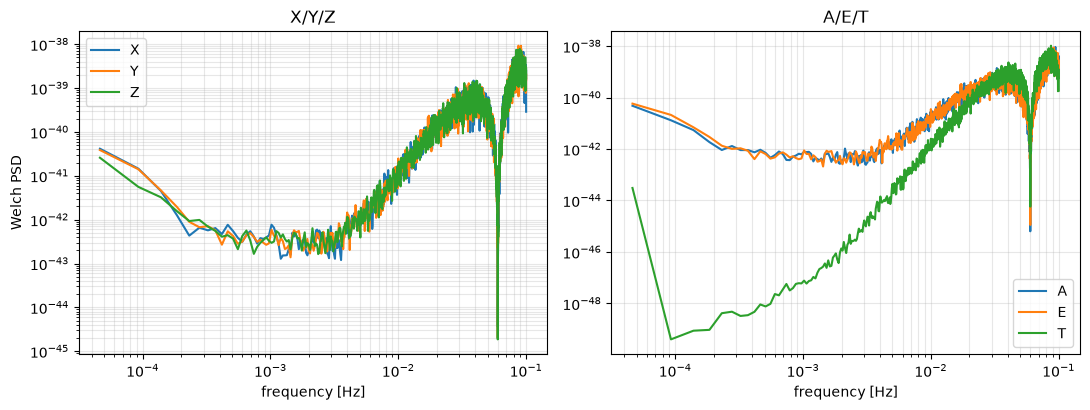

In [16]:

fs = 1.0 / dt
nperseg = min(8192, noise_xyz["X"].size // 4)

psd_xyz, psd_aet = {}, {}
for ch in XYZ:
    freq, psd_xyz[ch] = welch(noise_xyz[ch], fs=fs, nperseg=nperseg, detrend="constant")
for ch in AET:
    _, psd_aet[ch] = welch(noise_aet[ch], fs=fs, nperseg=nperseg, detrend="constant")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ch in XYZ:
    axes[0].loglog(freq[1:], psd_xyz[ch][1:], label=ch)
axes[0].set_title("X/Y/Z")

for ch in AET:
    axes[1].loglog(freq[1:], psd_aet[ch][1:], label=ch)
axes[1].set_title("A/E/T")

for ax in axes:
    ax.set_xlabel("frequency [Hz]")
    ax.grid(alpha=0.3, which="both")
    ax.legend()
axes[0].set_ylabel("Welch PSD")

fig.tight_layout()
plt.show()


# Likelihood

In [12]:
def fdom(x, dt):
    n = x.size
    xf = np.fft.rfft(x) * dt
    freq = np.fft.rfftfreq(n, d=dt)
    return freq, xf



In [ ]:
ll_chan = ("A", "E") #exclude T cuz we hate it C:
